In [1]:
def parse_scientific(float_number, precision=2):
    float_str = f"{float_number:.{precision}e}"
    base, exponent = float_str.split('e')
    exponent = int(exponent)
    return f'${base}\\times$\n' + '$10^{' + str(exponent) + '}$'

In [2]:
import numpy as np
dark_pink = tuple(np.array([242, 56,  90 , 255]) / 255.)
medium_turquoise = tuple(np.array([54,  177, 191, 255]) / 255.)

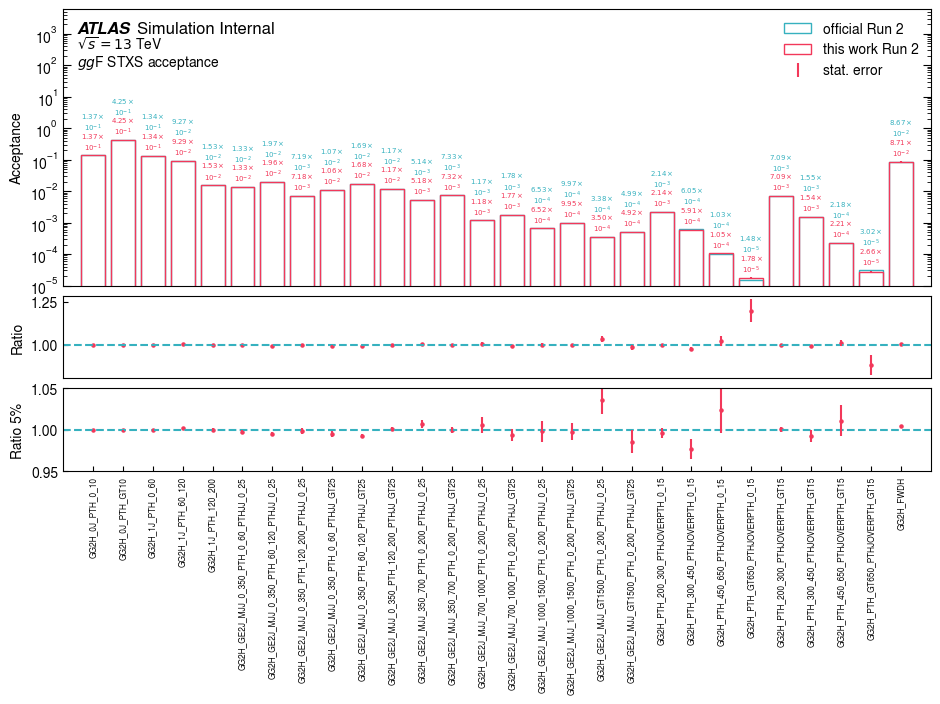

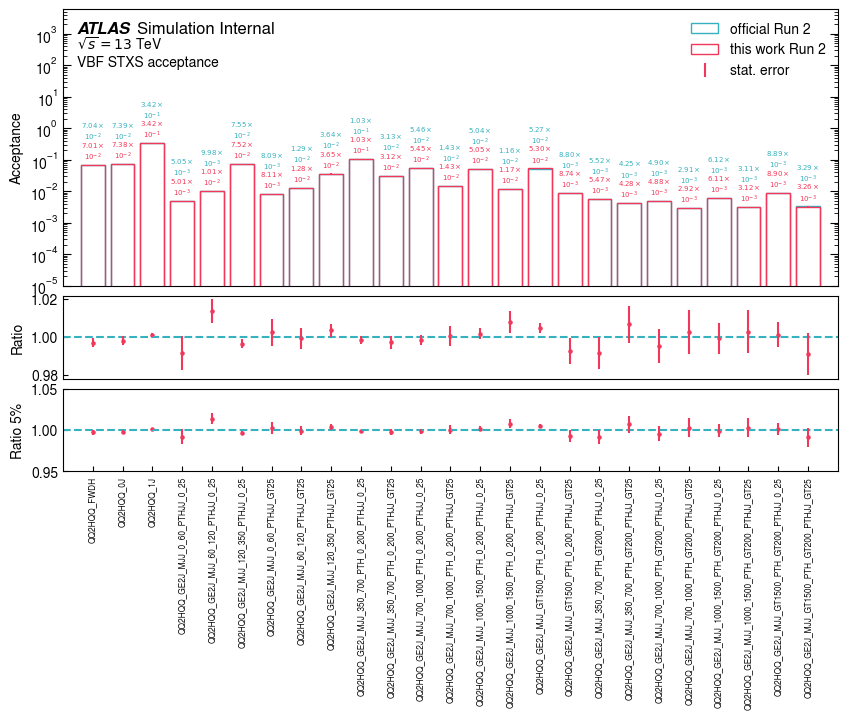

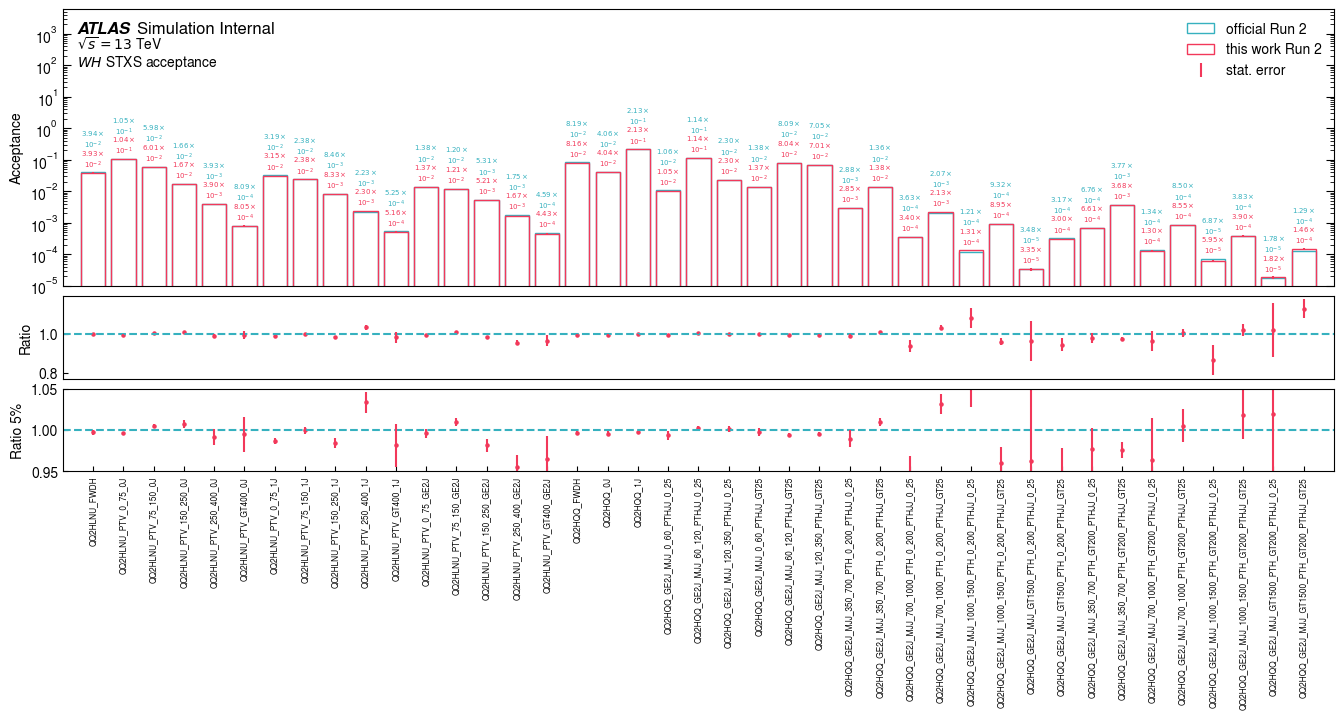

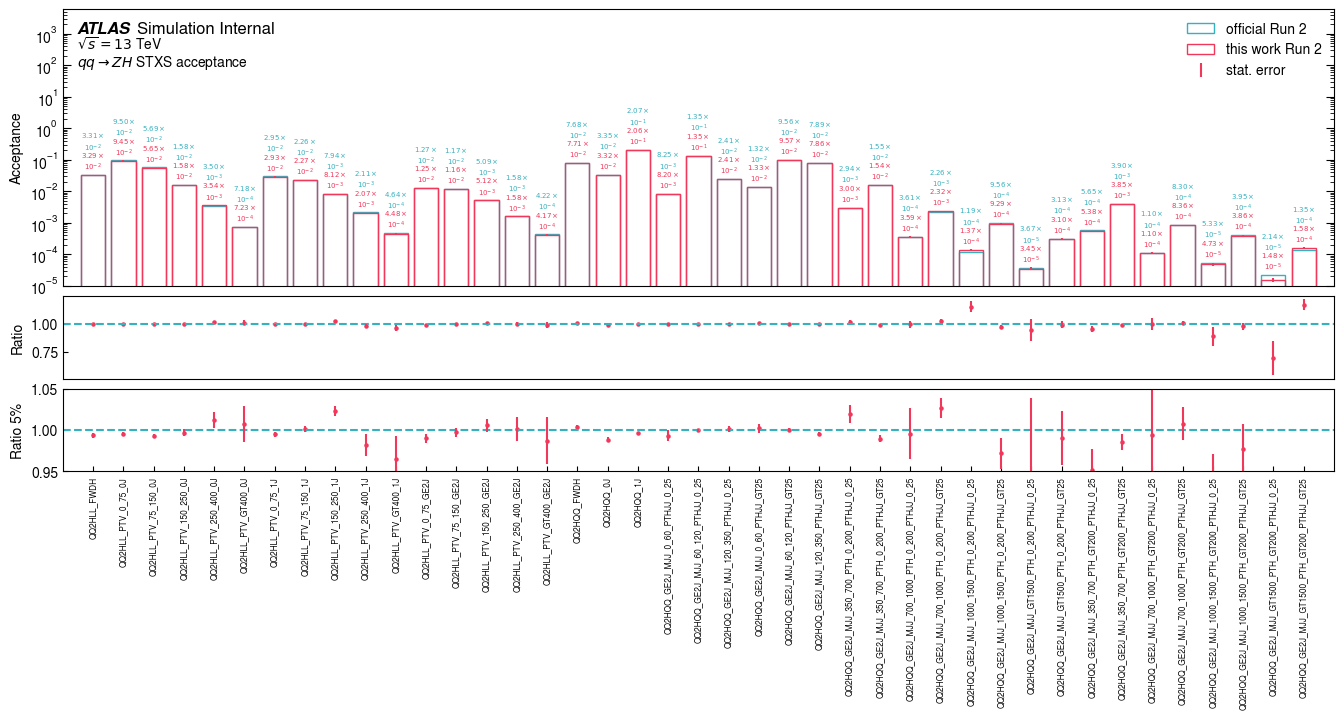

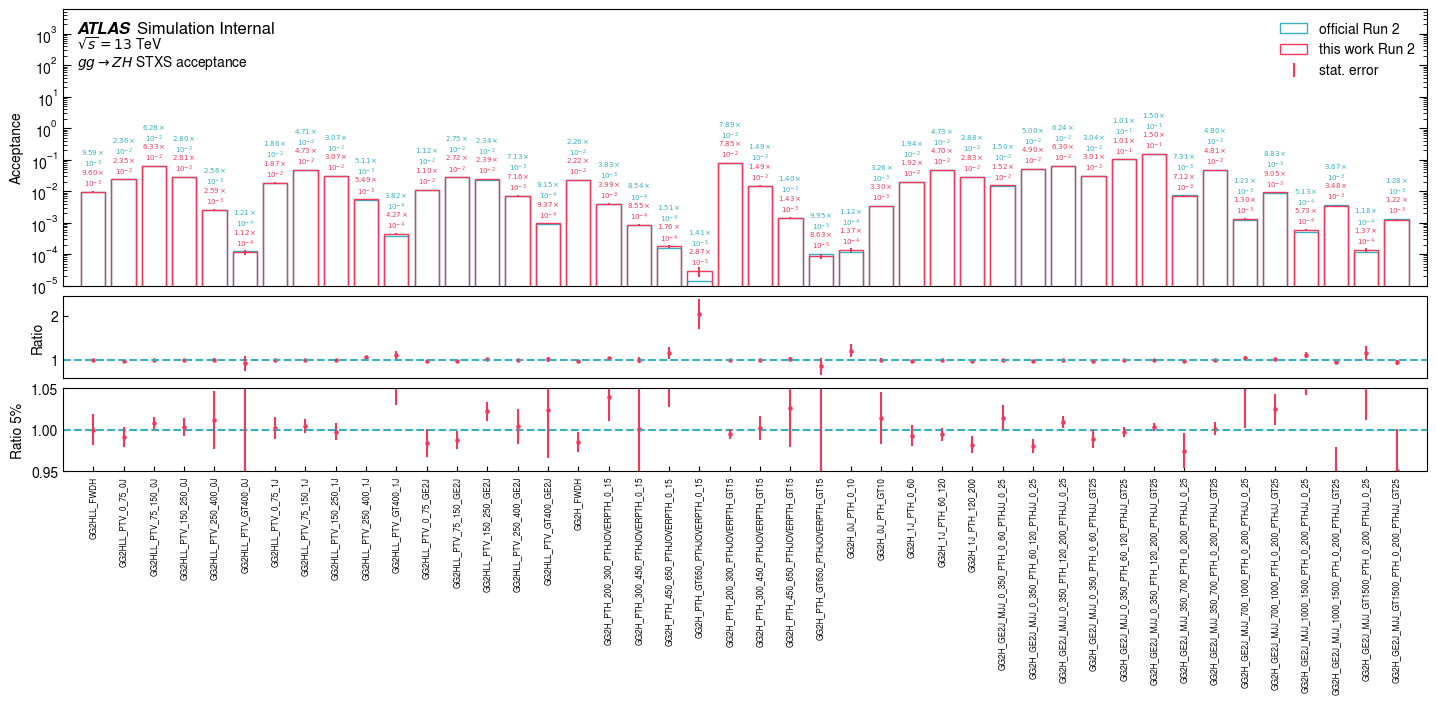

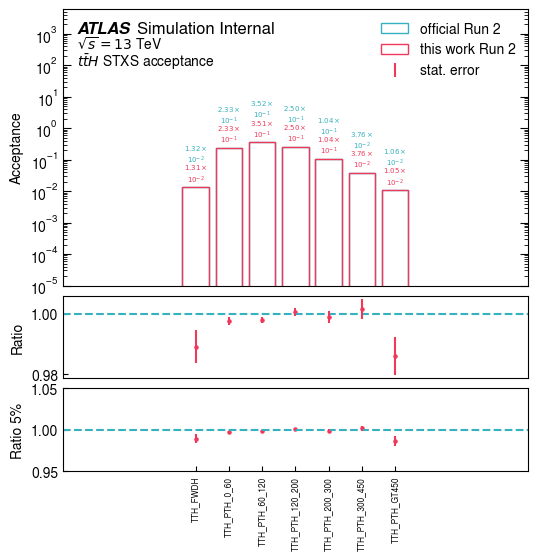

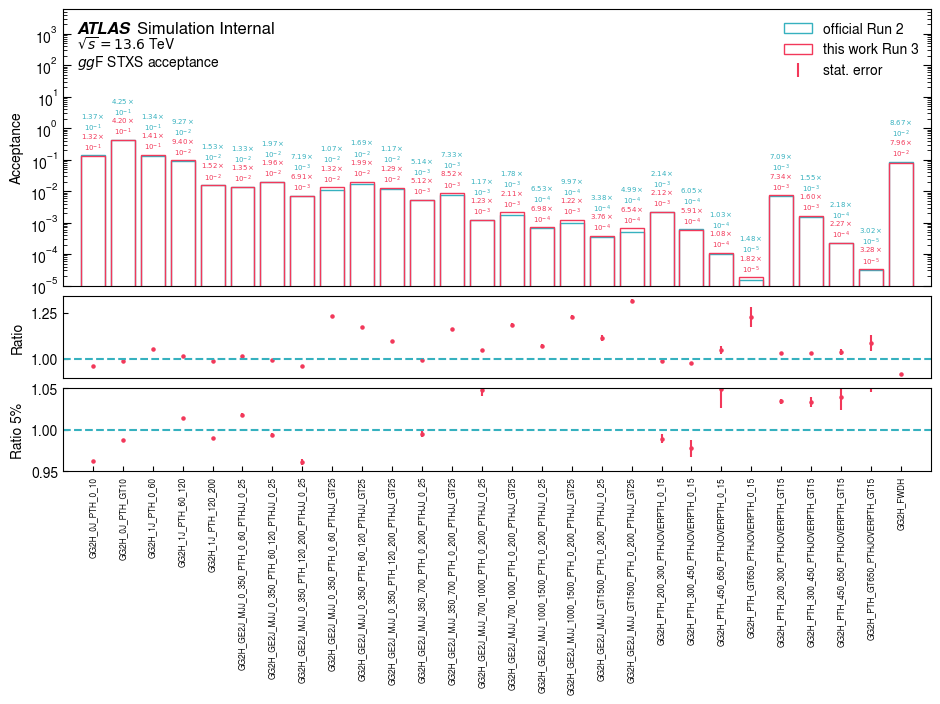

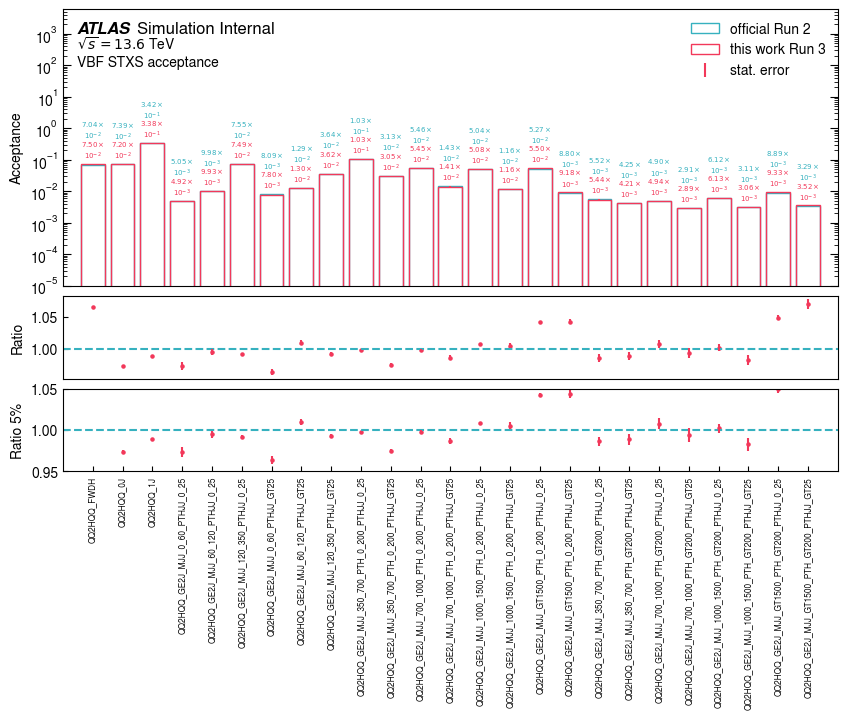

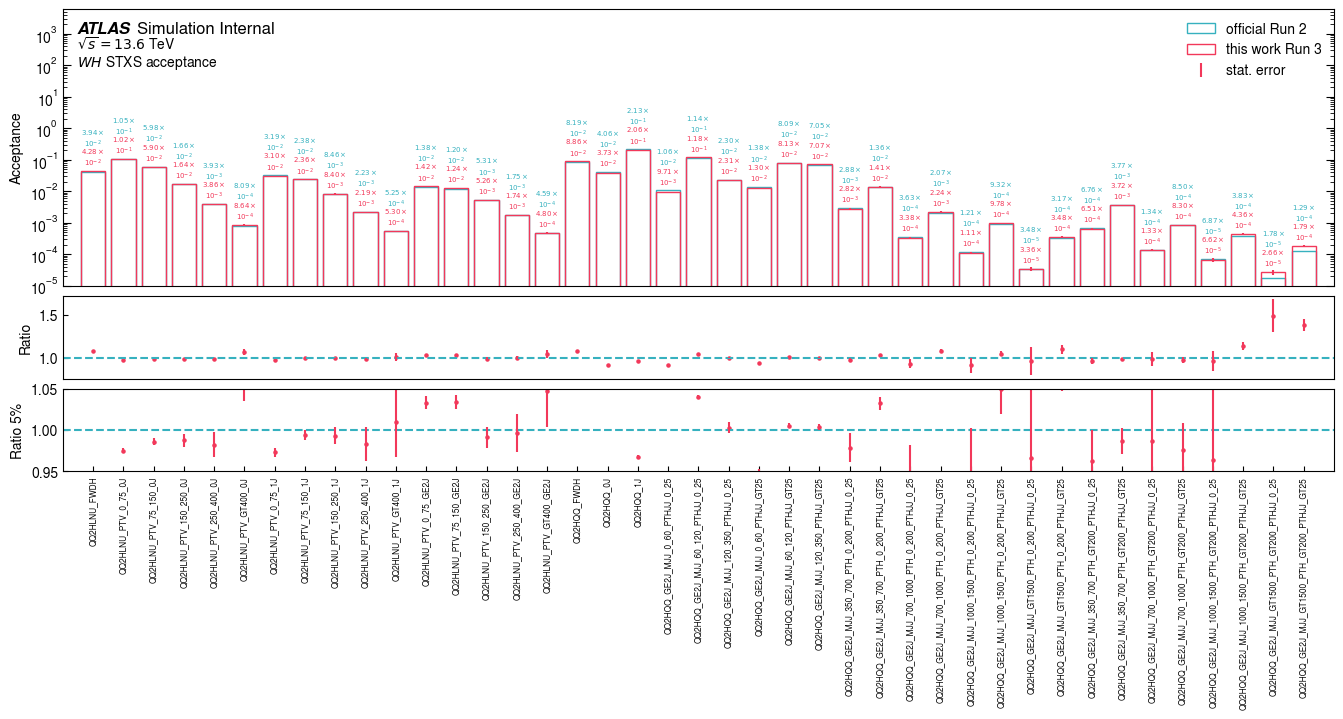

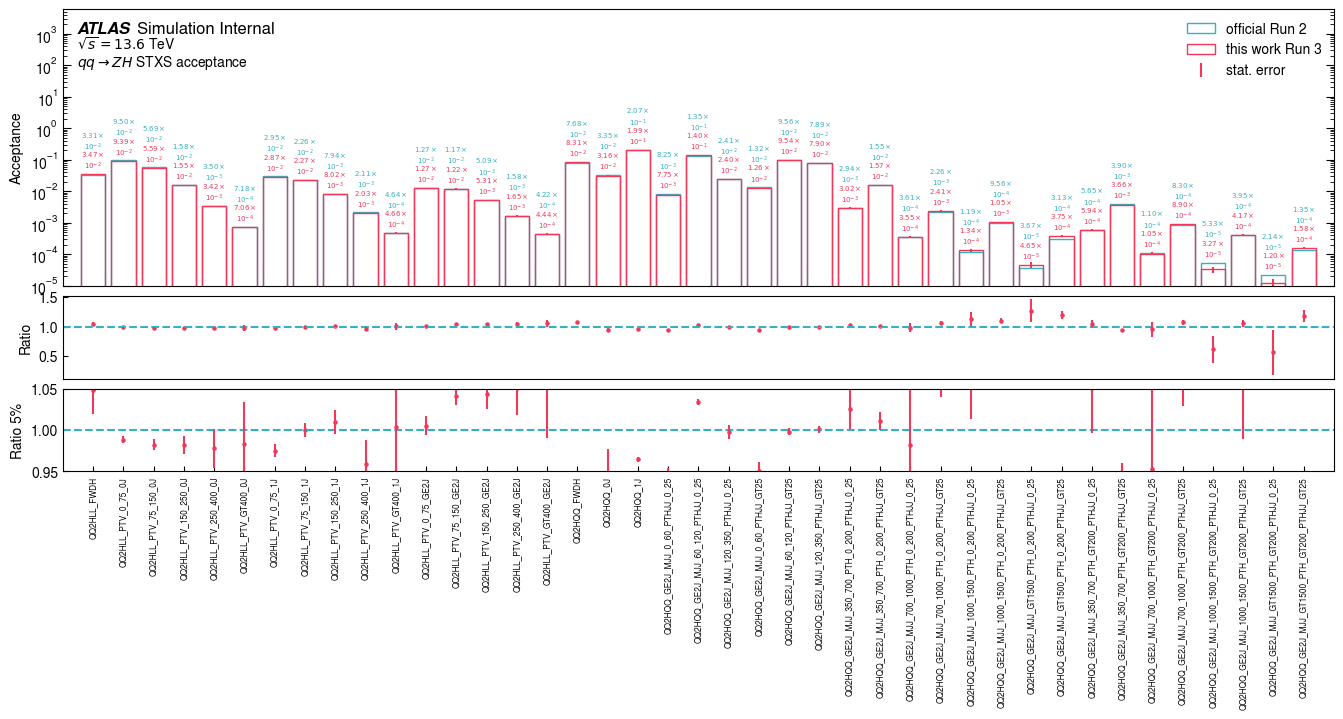

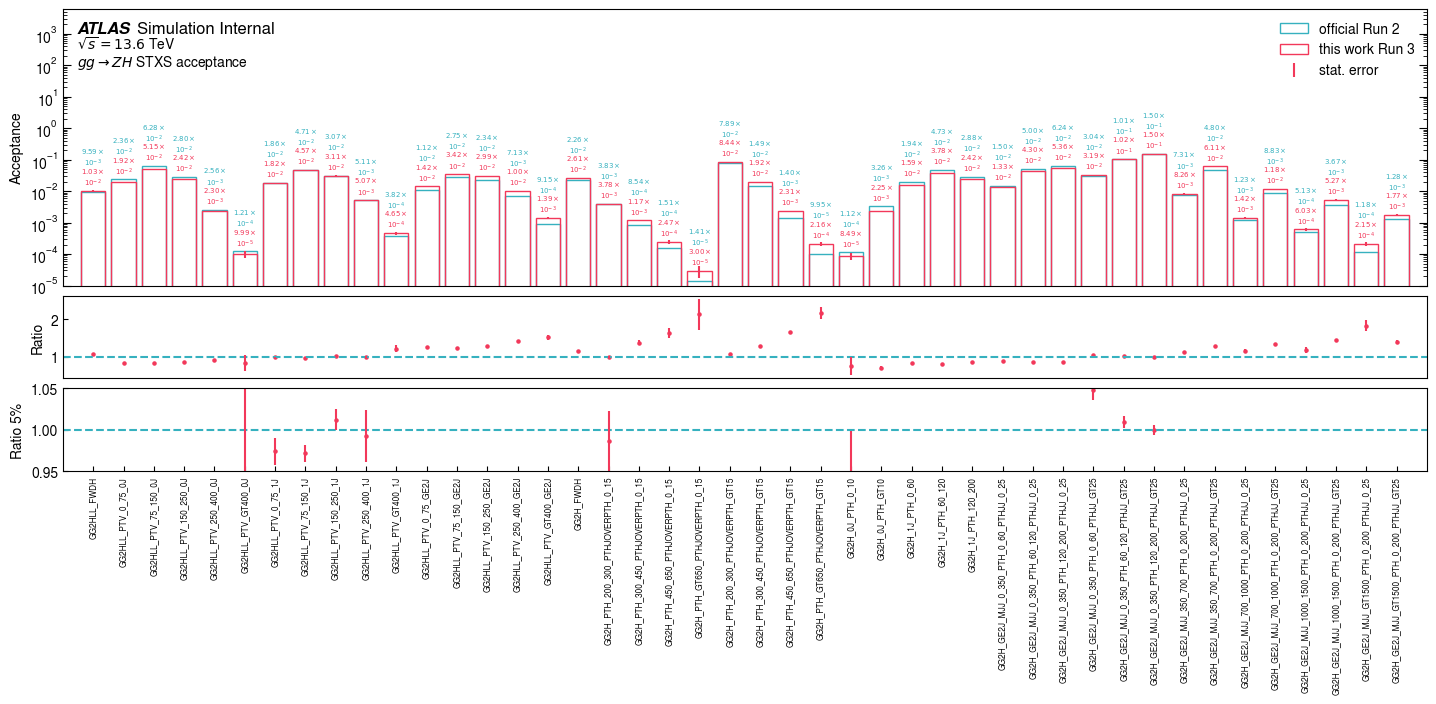

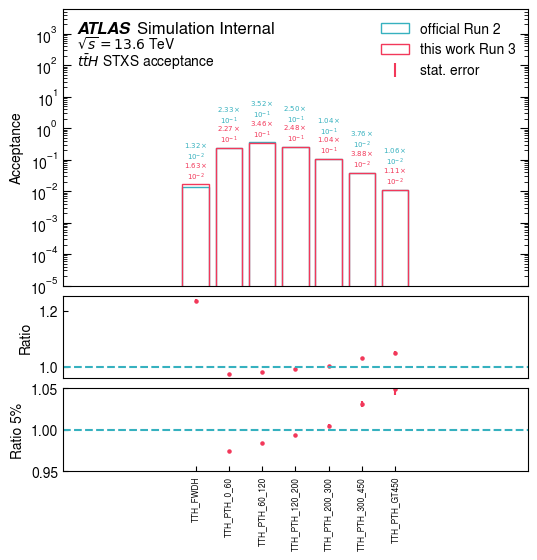

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
import libPy
import atlasify
atlasify.FONT_SIZE = 12
atlasify.LABEL_FONT_SIZE = 12
atlasify.SUB_FONT_SIZE = 10

# plt.rcParams["font.family"] = "monospace"

channels =  [
    ("mc20_ggf_hyy" , '$gg$F'),
    ("mc20_vbf_hyy" , 'VBF'),
    ('mc20_wh_hyy'  , '$WH$'),
    ('mc20_qqzh_hyy', '$qq\\to ZH$'),
    ('mc20_ggzh_hyy', '$gg\\to ZH$'),
    ('mc20_tth_hyy' , '$t\\bar{t}H$'),
    ("mc23_ggf_hyy" , '$gg$F'),
    ("mc23_vbf_hyy" , 'VBF'),
    ('mc23_wh_hyy'  , '$WH$'),
    ('mc23_qqzh_hyy', '$qq\\to ZH$'),
    ('mc23_ggzh_hyy', '$gg\\to ZH$'),
    ('mc23_tth_hyy' , '$t\\bar{t}H$'),
]

for channel, label in channels:
    run = 2 if 'mc20' in channel else 3
    pdf_values = pd.read_csv(f"res_stxs/{channel}.csv", index_col=0)
    pdf_error = pd.read_csv(f"res_stxs/{channel}_error.csv", index_col=0)

    official = {key.upper() : val for key, val in libPy.official_1_2_fine_run2[channel.split('_')[1]].items()}
    mine = pdf_values.iloc[0]
    mine.index = [index.upper() for index in mine.index]
    mine_error = pdf_error.iloc[0]
    mine_error.index = [index.upper() for index in mine_error.index]
    comp_df = pd.DataFrame.from_dict(official, orient='index')
    comp_df = comp_df / 100.0
    comp_df.columns = ['official']
    comp_df['mine'] = mine
    comp_df['mine_stat_error'] = mine_error
    comp_df['diff'] = comp_df['mine'] - comp_df['official']
    comp_df['diff_ratio_1'] = (comp_df['mine'] - comp_df['official']) / comp_df['official'] * 100
    comp_df['diff_ratio'] = comp_df['mine'] / comp_df['official']
    comp_df['diff_ratio_error'] = comp_df['mine_stat_error'] / comp_df['mine']


    fig, ax = plt.subplots(figsize=(comp_df.shape[0]*0.4 if comp_df.shape[0]*0.4 > 15*0.4 else 15*0.4, 6))
    # ax.grid(axis='y')
    ax.bar(comp_df.index, comp_df['official'], label='official Run 2', color='#00000000', edgecolor=medium_turquoise, width=0.8, align='center')
    ax.bar(comp_df.index, comp_df['mine'], label=f'this work Run {run}', color='#00000000', edgecolor=dark_pink, width=0.8, align='center')
    ax.errorbar(comp_df.index, comp_df['mine'], yerr=comp_df['mine_stat_error'], fmt='none', ecolor=dark_pink, label='stat. error')
    for idx, row in comp_df.iterrows():
        ax.text(idx, max(row['official'], row['mine'])*1.2, parse_scientific(row['mine']), ha='center', va='bottom', fontsize=5, color=dark_pink, style='oblique')
        ax.text(idx, max(row['official'], row['mine'])*25, parse_scientific(row['official']), ha='center', va='top', fontsize=5, color=medium_turquoise, style='oblique')
    ax.set_ylabel('Acceptance')
    ax.legend(fancybox=False, framealpha=0.0)
    ax.set_ylim(1e-5, 1e4)
    ax.semilogy()
    ax.get_xaxis().set_visible(False)
    divider = make_axes_locatable(ax)
    ax_ratio = divider.append_axes("bottom", size="30%", pad=0.1, sharex=ax)
    ax_ratio.axhline(1, color=medium_turquoise, linestyle='--')
    ax_ratio.errorbar(comp_df.index, comp_df['diff_ratio'], yerr=comp_df['diff_ratio_error'], fmt='none', ecolor=dark_pink)
    ax_ratio.scatter(comp_df.index, comp_df['diff_ratio'], color=dark_pink, s=5)
    ax_ratio.set_ylabel('Ratio')
    ax_ratio.get_xaxis().set_visible(False)
    ax_ratio_fine = divider.append_axes("bottom", size="30%", pad=0.1, sharex=ax)
    ax_ratio_fine.axhline(1, color=medium_turquoise, linestyle='--')
    ax_ratio_fine.errorbar(comp_df.index, comp_df['diff_ratio'], yerr=comp_df['diff_ratio_error'], fmt='none', ecolor=dark_pink)
    ax_ratio_fine.scatter(comp_df.index, comp_df['diff_ratio'], color=dark_pink, s=5)
    ax_ratio_fine.set_ylabel('Ratio 5%')
    ax_ratio_fine.set_ylim(0.95, 1.05)
    if comp_df.shape[0] < 15:
        ax_ratio_fine.set_xlim(-(15 - comp_df.shape[0])/2, comp_df.shape[0] + (15 - comp_df.shape[0])/2 - 1)
    else:
        ax_ratio_fine.set_xlim(-1, comp_df.shape[0])
    ax_ratio.tick_params(axis='both', which='both', direction="in")
    ax.tick_params(axis='both', which='both', direction="in")
    ax_ratio_fine.tick_params(axis='x', which='minor', color='white')
    ax_ratio_fine.tick_params(axis='y', which='both', direction="in")
    ax_ratio_fine.tick_params(axis='x', which='major', labelsize=6, rotation=90, direction="in")
    atlasify.atlasify('Simulation Internal', ('$\\sqrt{s}=13.6$ TeV\n' if run == 3 else '$\\sqrt{s}=13$ TeV\n') + f'{label} STXS acceptance', enlarge=0.6, axes=ax)
    fig.savefig(f'plots_stxs/{"_".join(channel.split("_")[0:2])}.pdf', bbox_inches='tight')